<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/Descriptive_Statistic__Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Descriptive Statistics Exercise**



In [1]:
# importing libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import normaltest

**1. Load the all_cars.csv dataset you just created and save it in a variable named 'df_car'.**\
&emsp;• If there is a column named 'Unnamed: 0', rename it to 'id'!\
&emsp;• If there isn't one, reset the index. Then, change the leftmost column named 'index' to 'id'!

In [2]:
# loading dataset
all_cars_csv = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vSbFVzCI9w7S4l3bdrTjR9saajaHuH3MJO5i3Fl4M9aGI8uY8ii3ZWS0kVnkJ5wENGqSXpyo-34fMcM/pub?gid=116408873&single=true&output=csv'

# review 5 top rows
df_car = pd.read_csv(all_cars_csv)
df_car.head()


,Unnamed: 0,brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,0,Audi,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,1,Audi,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,2,Audi,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,3,Audi,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,4,Audi,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


In [3]:
# renaming a column
df_car = df_car.rename(columns={'Unnamed: 0':'id'})
df_car.head()

,id,brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,0,Audi,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,1,Audi,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,2,Audi,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,3,Audi,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,4,Audi,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


**2. Display the statistical description of the df_car dataset.**

In [4]:
# numeric columns
df_car.describe()

,id,year,price,mileage,tax,mpg,engineSize
count,22038.000000,22038.000000,22038.000000,22038.000000,22038.000000,22038.000000,22038.000000
mean,11018.500000,2016.982303,17522.086033,23613.609946,115.353934,55.208531,1.690453
std,6361.966952,2.134123,10587.356894,21063.202824,69.024931,14.851751,0.566645
min,0.000000,1997.000000,850.000000,1.000000,0.000000,1.100000,0.000000
25%,5509.250000,2016.000000,9999.000000,7446.250000,30.000000,45.600000,1.400000
50%,11018.500000,2017.000000,14999.000000,18539.500000,145.000000,55.400000,1.600000
75%,16527.750000,2019.000000,21990.000000,33186.750000,145.000000,64.200000,2.000000
max,22037.000000,2020.000000,145000.000000,323000.000000,580.000000,256.800000,6.300000


In [5]:
# categorical columns
df_car.describe(include='object')

,brand,model,transmission,fuelType
count,22038,22038,22038,22038
unique,3,60,4,4
top,Audi,Yaris,Manual,Petrol
freq,10565,2117,11656,11896


**3. We know that variables are divided into two types: qualitative and quantitative.**

* Qualitative variables are divided into two types: nominal and ordinal.

* Quantitative variables are divided into two types: continuous and discrete.

* Which columns do you think are qualitative variables? (Which are nominal and ordinal?)

* Which columns do you think are quantitative variables? (Which are continuous and which are discrete?)

In [6]:
df_car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22038 entries, 0 to 22037
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            22038 non-null  int64  
 1   brand         22038 non-null  object 
 2   model         22038 non-null  object 
 3   year          22038 non-null  int64  
 4   price         22038 non-null  int64  
 5   transmission  22038 non-null  object 
 6   mileage       22038 non-null  int64  
 7   fuelType      22038 non-null  object 
 8   tax           22038 non-null  int64  
 9   mpg           22038 non-null  float64
 10  engineSize    22038 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 1.8+ MB


`Var. Qualitative / Categorical`
- Nominal: id, brand, model, transmission, fuelType
- Ordinal : -

`Var. Quantitative / Numerical`
- Discrete : year
- Continue : price, mileage, tax, mpg, engineSize

**4. What is a Measure of Central Tendency? Display the Measure of Central Tendency from the 'model' and 'price' columns! What Central Tendency is appropriate for the 'model' and 'price' columns?**

- A measure used to describe the central position of a frequency distribution for a set of data.
- Another term --> Estimate of Location: an estimate of where most of the data is located
(Practical Statistics for Data Science - Bruce, 2021)

In [7]:
# model --> modus
df_car['model'].mode()[0]

'Yaris'

In [8]:
# price --> mean (if normal distribution)
print(df_car['price'].mean())

17522.086033215357


In [9]:
# price --> median (if not normally distributed)
print(df_car['price'].median())

14999.0


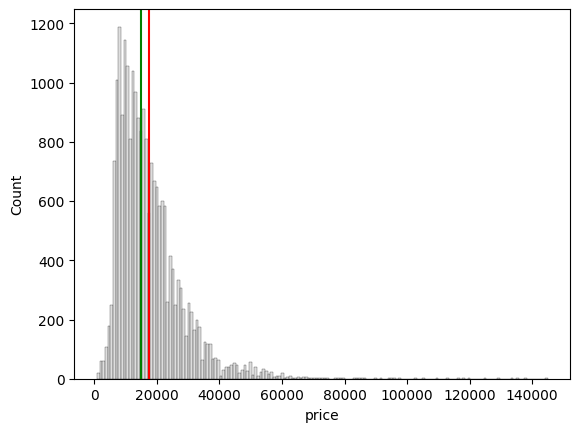

In [10]:
# Visualization
sns.histplot(df_car['price'], color='lightgray')
plt.axvline(x= df_car['price'].mean(), color='red')
plt.axvline(x=df_car['price'].median(), color='green')
plt.show()

**5. What is Measure of Spread? Show Measure of Spread from the 'price' column!**

- A measurement to describe how spread out our data is.
- Another term --> Estimates of Variability/Dispersion

Examples: Range, Standard Deviation, IQR

In [11]:
# range
max = df_car['price'].max()
min = df_car['price'].min()

range = max - min
range

144150

In [12]:
# standar deviation
df_car['price'].std()

10587.356893932203

In [13]:
# IQR
# IQR
Q1 = df_car['price'].quantile(0.25)
Q3 = df_car['price'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

11991.0


**6. Are there any outliers in the 'price' column? If so, how many of the data are outliers?**

In [14]:
outlier_upper_limit = Q3 + 1.5 * IQR
outlier_lower_limit = Q1 - 1.5 * IQR

print('Upper limit:', outlier_upper_limit)
print('Lower limit:', outlier_lower_limit)

Upper limit: 39976.5
Lower limit: -7987.5


In [15]:
number_of_outliers = len(df_car[(df_car['price'] < outlier_lower_limit) | (df_car['price'] > outlier_upper_limit)])

print('Number of Outliers:', number_of_outliers)

Number of Outliers: 802


**7. Which variables/columns have a distribution skewed to the right?**

Answer:

* Skewness is a measure of the asymmetry of the probability distribution of a random variable about its mean.

* The skewness value can be positive or negative, or even undefined. If the skewness is 0, the data is perfectly symmetric, although this is unlikely for real-world data. As a general rule of thumb:

  * If the skewness is less than -1 or greater than 1, the distribution is highly skewed.
  * If the skewness is between -1 and -0.5 or between 0.5 and 1, the distribution is slightly skewed.
  * If the skewness is between -0.5 and 0.5, the distribution is approximately symmetric.

Positive skewness indicates right-skewed or positively skewed data (not normally distributed).

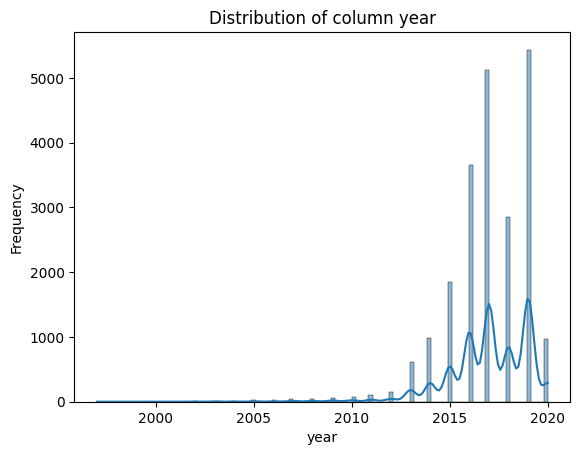

<Figure size 600x400 with 0 Axes>

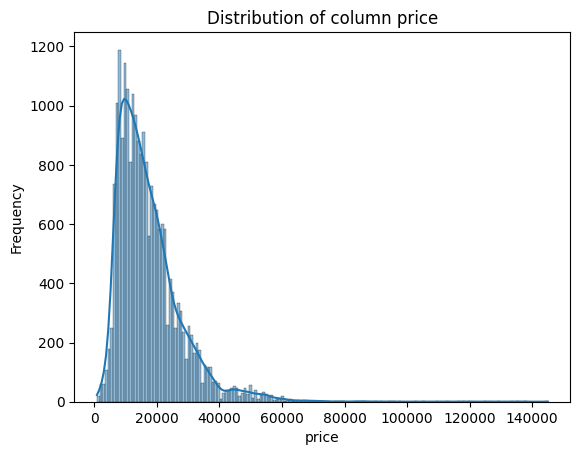

<Figure size 600x400 with 0 Axes>

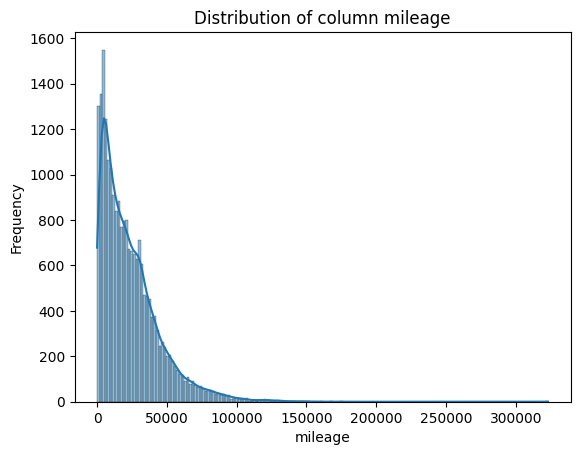

<Figure size 600x400 with 0 Axes>

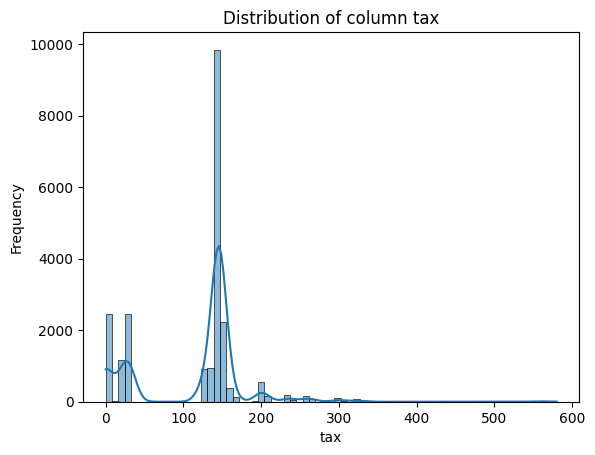

<Figure size 600x400 with 0 Axes>

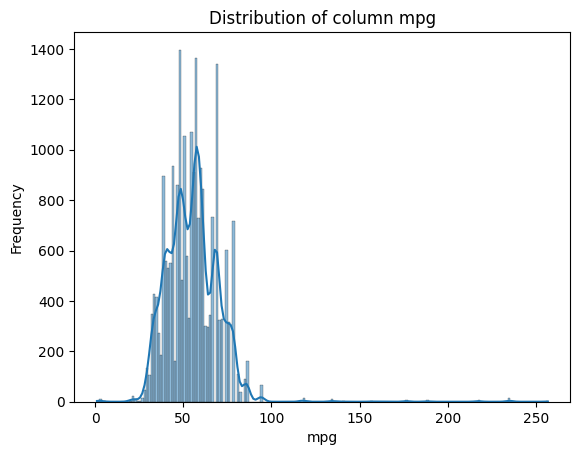

<Figure size 600x400 with 0 Axes>

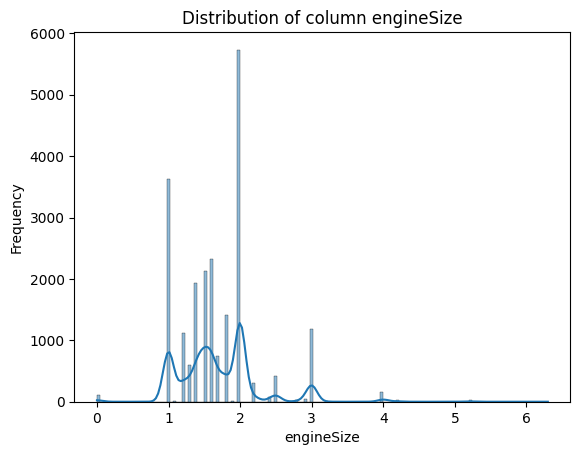

<Figure size 600x400 with 0 Axes>

In [16]:
# use visual methods
# Loop in df_car
for column in df_car.select_dtypes(include=['int64', 'float64']).columns:
  if column == 'id':
    continue
  # Create a histogram using Seaborn
  sns.histplot(data=df_car[column], kde=True)

  # Set title and labels
  plt.title(f'Distribution of column {column}')
  plt.xlabel(column)
  plt.ylabel('Frequency')

  # Setting the width and height of the figure
  plt.figure(figsize=(6,4))

  # Show the plot
  plt.show()

In [17]:
# Method 2: Skew Calculation
numerics = ['price', 'mileage', 'tax', 'mpg', 'engineSize', 'year']

for column in numerics:
  print(f'{column} : {df_car[column].skew():.2f}')

price : 2.32
mileage : 1.69
tax : 0.15
mpg : 2.45
engineSize : 1.19
year : -1.75


In [18]:
# Method 3
# Apply the skew() function to each numeric column only
for column in df_car.select_dtypes(include=['int64', 'float64']).columns:
  skewness = df_car[column].skew()
  if skewness > 0.5:
      skewness_desc = "right skewed"
  else:
      skewness_desc = "not right skewed"

  print(f"The skewness of column {column} is {skewness}, so it includes ({skewness_desc})")

The skewness of column id is 0.0, so it includes (not right skewed)
The skewness of column year is -1.754000724578943, so it includes (not right skewed)
The skewness of column price is 2.320118546492954, so it includes (right skewed)
The skewness of column mileage is 1.6940196691820135, so it includes (right skewed)
The skewness of column tax is 0.1548300092018357, so it includes (not right skewed)
The skewness of column mpg is 2.448038962962843, so it includes (right skewed)
The skewness of column engineSize is 1.1926597551538234, so it includes (right skewed)


**8. The mean and median values for the 'mileage' column are significantly different. Test whether the column is normally distributed or not!**

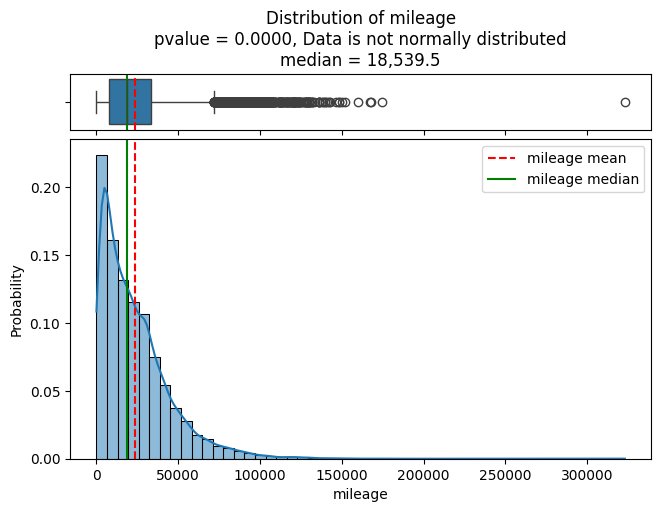

In [19]:
fig, (ax1, ax2) = plt.subplots(2, sharex = True, figsize = (7.5,5),
                                   gridspec_kw={"height_ratios": (.15, .85),
                                               "hspace": 0.05})

pvalue=normaltest(df_car['mileage'])[1]

if pvalue > 0.05 :
    text = (f'pvalue = {pvalue:.4f}, Data is normally ditributed')
else :
    text = (f'pvalue = {pvalue:.4f}, Data is not normally distributed')

ax1.set_title(f"Distribution of mileage\n{text}\nmedian = {df_car['mileage'].median():,.1f}", color = "black")
sns.boxplot(x = df_car['mileage'], ax = ax1)
ax1.axvline(df_car['mileage'].mean(), color='r', linestyle='--')
ax1.axvline(df_car['mileage'].median(), color='g', linestyle='-')
ax1.set(xlabel = "")
sns.histplot(data = df_car['mileage'], ax = ax2, stat = "probability", kde=True, bins=50)
ax2.axvline(df_car['mileage'].mean(), color='r', linestyle='--', label='mileage mean')
ax2.axvline(df_car['mileage'].median(), color='g', linestyle='-', label='mileage median')
plt.legend()
plt.show()

**9. What graph is suitable for displaying the following visualizations:**
* brand vs. price
* price vs. mileage
* frequency distribution of mileage

`brand vs price`

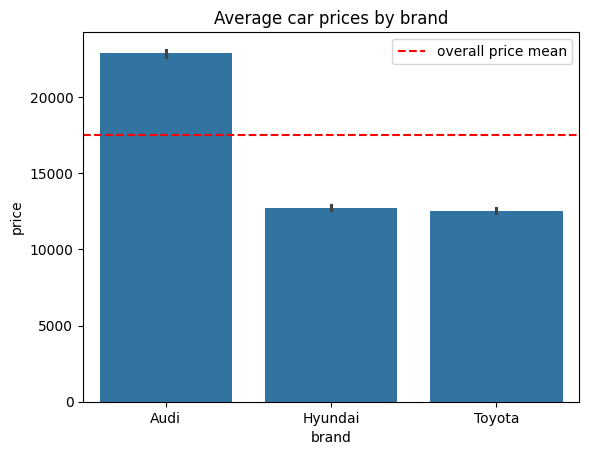

In [20]:
# brand vs price (categorical vs numerical --> barchart)

sns.barplot(data=df_car, x='brand', y='price')
plt.title('Average car prices by brand')
plt.axhline(y=df_car['price'].mean(), color='red', linestyle='--', label='overall price mean')
plt.legend()
plt.show()

`price vs mileage`

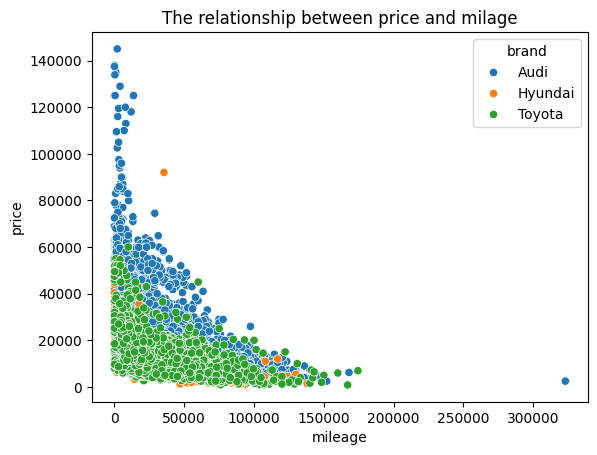

In [23]:
# price vs mileage (numeric vs numeric --> scatterplot)
sns.scatterplot(data=df_car, y='price', x='mileage', hue='brand')
plt.title('The relationship between price and milage')
plt.show()

`frequency distribution of mileage`

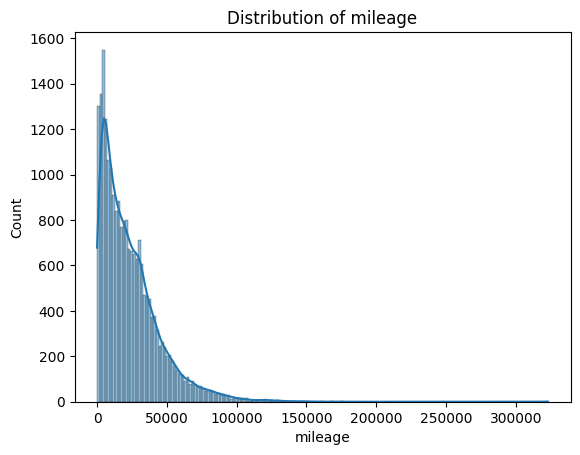

In [24]:
# Frequency distribution of mileage
sns.histplot(data=df_car, x='mileage', kde=True)
plt.title('Distribution of mileage')
plt.show()